In [8]:
!ls -lh /content/*.zip

-rw-r--r-- 1 root root 239M Oct  7 05:07 /content/archive.zip


In [9]:
!unzip -q /content/archive.zip -d /content/aptos
!ls /content/aptos
!ls /content/aptos/colored_images

colored_images	train.csv
Mild  Moderate	No_DR  Proliferate_DR  Severe


In [10]:
import os, glob, cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt

BASE  = '/content/aptos'
ORDER = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']

def crop_black(img, tol=7):
    m = img.mean(axis=2) > tol
    if m.sum() == 0: return img
    ys, xs = np.where(m)
    return img[ys.min():ys.max(), xs.min():xs.max()]

def load_rgb(path, size=256):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    return cv2.resize(crop_black(img), (size, size))

def enhance(img, size=256):
    return cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), size/30), -4, 128)

for c in ORDER:
    print(c, len(os.listdir(f'{BASE}/colored_images/{c}')))

No_DR 1805
Mild 370
Moderate 999
Severe 193
Proliferate_DR 295


done: 3662 images


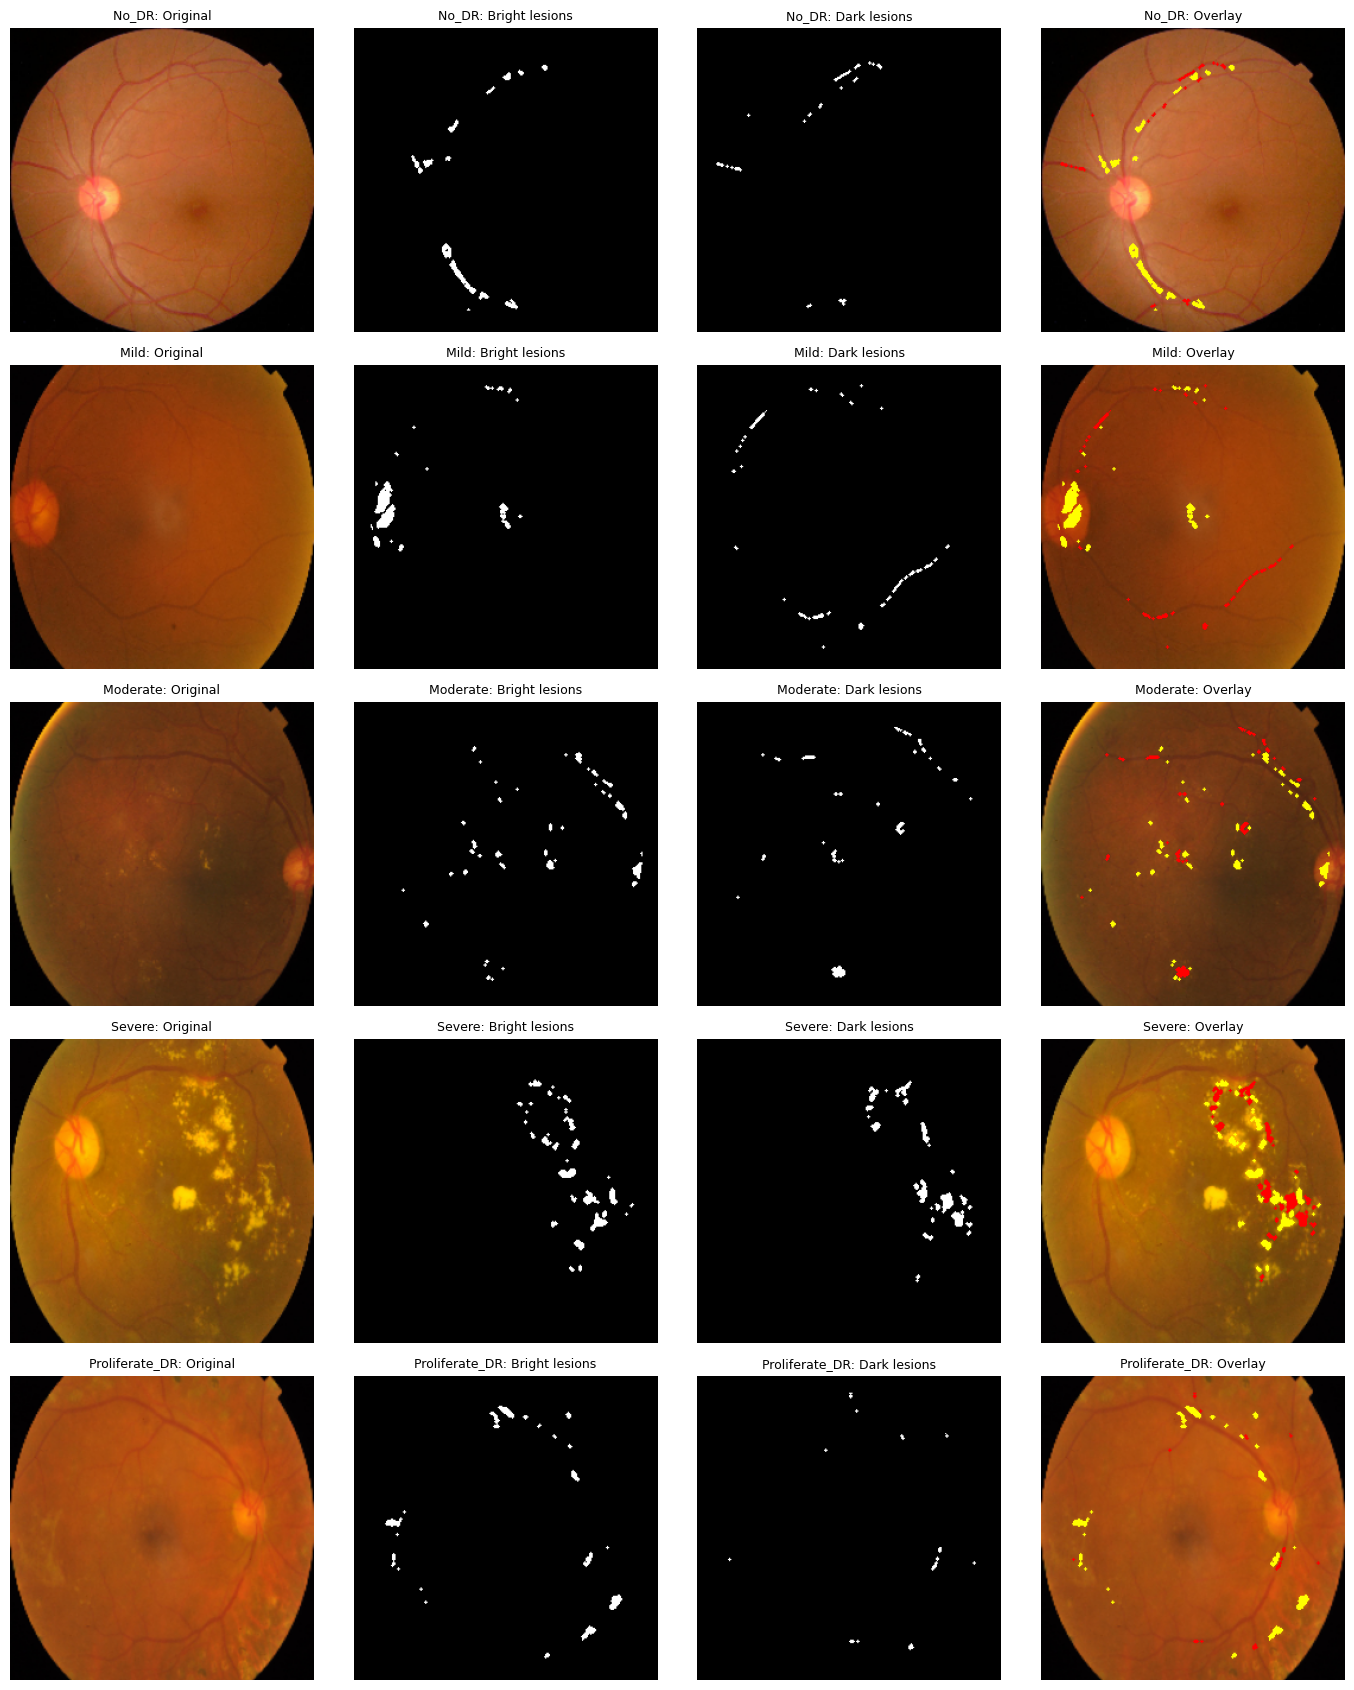

In [12]:
import cv2, numpy as np, matplotlib.pyplot as plt, glob, os

BASE = '/content/aptos'
PREP = '/content/prep'
ORDER = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']

def crop_black(img, tol=7):
    m = img.mean(axis=2) > tol
    if m.sum() == 0: return img
    ys, xs = np.where(m)
    return img[ys.min():ys.max(), xs.min():xs.max()]

def load_rgb(path, size=256):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    return cv2.resize(crop_black(img), (size, size))

def enhance(img, size=256):
    return cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), size/30), -4, 128)

# Prepare preprocessed images
for gi, c in enumerate(ORDER):
    os.makedirs(f'{PREP}/{c}', exist_ok=True)
    for p in glob.glob(f'{BASE}/colored_images/{c}/*.png'):
        out = enhance(load_rgb(p))
        cv2.imwrite(f'{PREP}/{c}/{os.path.basename(p)}', cv2.cvtColor(out, cv2.COLOR_RGB2BGR))
print('done:', sum(len(os.listdir(f'{PREP}/{c}')) for c in ORDER), 'images')

def fov_mask(img, erode=12):
    g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    m = (g > 15).astype(np.uint8)*255
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(15,15)))
    h,w = m.shape
    ell = np.zeros_like(m); cv2.ellipse(ell,(w//2,h//2),(w//2-2,h//2-2),0,0,360,255,-1)
    m = cv2.bitwise_and(m, ell)
    return cv2.erode(m, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(erode*2+1,erode*2+1)))

def optic_disc_mask(g, fov, r=28):
    blur = cv2.GaussianBlur(g,(0,0),12); blur[fov==0]=0
    _,_,_,loc = cv2.minMaxLoc(blur)
    m = np.zeros_like(g); cv2.circle(m, loc, r, 255, -1); return m

def keep_blobs(mask, min_area, max_area, max_aspect):
    n, lab, st, _ = cv2.connectedComponentsWithStats(mask, 8)
    out = np.zeros_like(mask)
    for i in range(1,n):
        x,y,w,h,a = st[i]
        asp = max(w,h)/max(1,min(w,h))
        if min_area<=a<=max_area and asp<=max_aspect: out[lab==i]=255
    return out

def segment(img):
    fov = fov_mask(img)
    g = cv2.createCLAHE(2.0,(8,8)).apply(img[:,:,1])
    od = optic_disc_mask(g, fov)
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(15,15))
    sm = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3))
    b = cv2.morphologyEx(g, cv2.MORPH_TOPHAT, se)
    d = cv2.morphologyEx(g, cv2.MORPH_BLACKHAT, se)
    def thr(x, pct):
        t = np.percentile(x[fov>0], pct); return ((x>t)*255).astype(np.uint8)
    b = thr(b, 97); d = thr(d, 96)
    b = cv2.morphologyEx(b, cv2.MORPH_OPEN, sm); d = cv2.morphologyEx(d, cv2.MORPH_OPEN, sm)
    b = cv2.bitwise_and(b, fov); d = cv2.bitwise_and(d, fov)
    b[od>0]=0; d[od>0]=0
    b = keep_blobs(b, 4, 400, 3.5)
    d = keep_blobs(d, 3, 150, 3.0)
    return g, fov, b, d

fig, ax = plt.subplots(5, 4, figsize=(14, 17))
for r, c in enumerate(ORDER):
    p = sorted(glob.glob(f'{BASE}/colored_images/{c}/*.png'))[0]
    img = load_rgb(p); g, fov, b, d = segment(img)
    ov = img.copy(); ov[b>0] = [255,255,0]; ov[d>0] = [255,0,0]
    for a, im, t in zip(ax[r], [img, b, d, ov], ['Original','Bright lesions','Dark lesions','Overlay']):
        a.imshow(im, cmap=None if im.ndim==3 else 'gray'); a.set_title(f'{c}: {t}', fontsize=9); a.axis('off')
plt.tight_layout(); plt.show()

In [13]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print('TensorFlow', tf.__version__)      # is version ko note kar lo
IMG, BATCH = 256, 32

rows = []
for gi, c in enumerate(ORDER):
    for f in glob.glob(f'{PREP}/{c}/*.png'):
        rows.append((f, gi))
meta = pd.DataFrame(rows, columns=['path', 'grade'])
tr, va = train_test_split(meta, test_size=0.2, stratify=meta.grade, random_state=42)
print(len(tr), len(va))

AUTOTUNE = tf.data.AUTOTUNE
def make_ds(d, training):
    ds = tf.data.Dataset.from_tensor_slices((d.path.values, d.grade.values.astype('int32')))
    def _load(path, label):
        img = tf.io.decode_png(tf.io.read_file(path), channels=3)
        img = tf.image.resize(img, (IMG, IMG))
        return img, label
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if training: ds = ds.shuffle(1000, seed=42)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

tr_ds, va_ds = make_ds(tr, True), make_ds(va, False)

cw = compute_class_weight('balanced', classes=np.arange(5), y=tr.grade.values)
class_weight = {i: float(w) for i, w in enumerate(cw)}
print(class_weight)

TensorFlow 2.21.0
2929 733
{0: 0.4056786703601108, 1: 1.979054054054054, 2: 0.7331664580725907, 3: 3.803896103896104, 4: 2.4822033898305085}


In [14]:
from tensorflow.keras import layers

aug = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])
base = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG, IMG, 3))
base.trainable = False

inp = tf.keras.Input((IMG, IMG, 3))
x = aug(inp)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(5, activation='softmax')(x)
model = tf.keras.Model(inp, out)

cbs = [
    tf.keras.callbacks.ModelCheckpoint('/content/best.keras', monitor='val_loss', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
]
model.compile(tf.keras.optimizers.Adam(1e-3), 'sparse_categorical_crossentropy', metrics=['accuracy'])
h1 = model.fit(tr_ds, validation_data=va_ds, epochs=8, class_weight=class_weight, callbacks=cbs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 179ms/step - accuracy: 0.5193 - loss: 1.3770 - val_accuracy: 0.6658 - val_loss: 0.9142 - learning_rate: 0.0010
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 134ms/step - accuracy: 0.6262 - loss: 1.1386 - val_accuracy: 0.6521 - val_loss: 0.8388 - learning_rate: 0.0010
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 130ms/step - accuracy: 0.6473 - loss: 1.0657 - val_accuracy: 0.7094 - val_loss: 0.7877 - learning_rate: 0.0010
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 124ms/step - accuracy: 0.6763 - loss: 1.0103 - val_accuracy: 0.6889 - val_loss: 0.7887 - learning_rate: 0.0010
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - accuracy: 0.6811 - loss: 0.9945 - val_accuracy: 0.7258 - val_loss: 0.7324 - learning_rate: 0.0010
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - accuracy: 0.6893 - loss: 0.9613 - val_accuracy: 0.7094 - val_loss: 0.7427 - learning_rate: 0.0010
Epoch 7/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 

In [15]:
base.trainable = True
for l in base.layers[:-30]:
    l.trainable = False
for l in base.layers:
    if isinstance(l, layers.BatchNormalization):
        l.trainable = False

model.compile(tf.keras.optimizers.Adam(1e-5), 'sparse_categorical_crossentropy', metrics=['accuracy'])
h2 = model.fit(tr_ds, validation_data=va_ds, epochs=12, class_weight=class_weight, callbacks=cbs)

Epoch 1/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 186ms/step - accuracy: 0.7088 - loss: 0.9240 - val_accuracy: 0.6999 - val_loss: 0.7442 - learning_rate: 1.0000e-05
Epoch 2/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 142ms/step - accuracy: 0.6934 - loss: 0.9299 - val_accuracy: 0.7231 - val_loss: 0.7177 - learning_rate: 1.0000e-05
Epoch 3/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step - accuracy: 0.7177 - loss: 0.9120 - val_accuracy: 0.7108 - val_loss: 0.7201 - learning_rate: 5.0000e-06
Epoch 4/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 138ms/step - accuracy: 0.7231 - loss: 0.8993 - val_accuracy: 0.7108 - val_loss: 0.7181 - learning_rate: 5.0000e-06


23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 336ms/step
Accuracy: 0.6999
Quadratic weighted kappa: 0.7562
                precision    recall  f1-score   support

         No_DR      0.952     0.942     0.947       361
          Mild      0.314     0.811     0.453        74
      Moderate      0.742     0.360     0.485       200
        Severe      0.432     0.410     0.421        39
Proliferate_DR      0.490     0.424     0.455        59

      accuracy                          0.700       733
     macro avg      0.586     0.589     0.552       733
  weighted avg      0.766     0.700     0.703       733



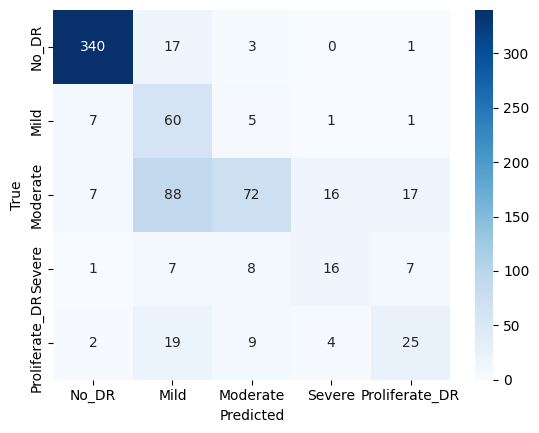

In [16]:
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score, accuracy_score
import seaborn as sns

probs = model.predict(va_ds)
y_pred = probs.argmax(1)
y_true = va.grade.values

print('Accuracy:', round(accuracy_score(y_true, y_pred), 4))
print('Quadratic weighted kappa:', round(cohen_kappa_score(y_true, y_pred, weights='quadratic'), 4))
print(classification_report(y_true, y_pred, target_names=ORDER, digits=3))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ORDER, yticklabels=ORDER)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()

In [17]:
model.save('/content/dr_model.keras')
from google.colab import files
files.download('/content/dr_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>